<a href="https://colab.research.google.com/github/AyleenSantander/M.11_Intro_AI/blob/main/M11_A_15_Loan_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 15: Loan Default Prediction
#Name Ayleen Santander

- Problem Statement:

A financial institution wants to predict which borrowers are likely to default on their loans. Your task is to:

1. Use a publicly available dataset related to loan default prediction.
2. Develop a machine learning model to predict loan defaults.
3. Evaluate the model performance and identify key factors influencing loan defaults.
4. Provide actionable recommendations to reduce the risk of defaults.

Summary of dataset:
1. 'age': Age of the customer
2. 'ed': Customer Education (1-5, ordinal)
3. 'employ': years with current employer
4. 'address': years at current address
5. 'income': in thousands
6. 'debtinc': debth to income %
7. 'creddebt': credit card debth
8. 'othdebt': relative with not bank loan
9. 'default': target variable, 1= default, 0= did not default


In [55]:
##Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score, f1_score
import hashlib
import os
!pip install shap
import shap
import io, os
from cryptography.fernet import Fernet
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_predict

#Task 1: Data Analysis and Cleaning
Data name : Bank_loan.csv


In [4]:
#1. #Step 1: Data Collection and Loading
# Load the dataset
loan = pd.read_csv('bank-loan.csv')
loan.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


In [7]:
#2. Perform exploratory data analysis (EDA) to understand the dataset./Display summary statistics.
#Visualize distributions and relationships between features.
# Display bank-laon dataset overview
print(loan.dtypes)
print('--'*45)
print(loan.info())
print('--'*45)
print(loan.describe())
print('--'*45)
print(loan.columns)

age           int64
ed            int64
employ        int64
address       int64
income        int64
debtinc     float64
creddebt    float64
othdebt     float64
default     float64
dtype: object
------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 59.9 KB
None
------------------------------------------------------------------------------------------
              age          ed      

In [8]:
#Verify missing values, duplicates
print(f'Missing values', loan.isnull().sum())
print('--'*45)
print(f'Duplicates', loan.duplicated().sum())

Missing values age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     150
dtype: int64
------------------------------------------------------------------------------------------
Duplicates 0


In [12]:
#8   default   700 non-null    float64, contain missing values, check are NaN
print(loan.isna().sum())

age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     150
dtype: int64


note: 150 rows are empty so that is the reason shows as nan, check below:

default is target variable: it marks whether the customer defaulted on their loan.

1 = defaulted (183 customers)
0 = did not default (517 customers)
NaN = 150 rows with no label

In [13]:
loan.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


In [17]:
#2. Perform exploratory data analysis (EDA) to understand the dataset./Display summary statistics.
#Visualize distributions and relationships between features.

# Work with labelled rows only
train = loan[loan['default'].notna()].copy()
train['default'] = train['default'].astype(int)

print(train.shape)
print(train.describe().round(2))
print("\nClass balance:")
print(train['default'].value_counts(normalize=True).round(3))

(700, 9)
          age      ed  employ  address  income  debtinc  creddebt  othdebt  \
count  700.00  700.00  700.00   700.00  700.00   700.00    700.00   700.00   
mean    34.86    1.72    8.39     8.28   45.60    10.26      1.55     3.06   
std      8.00    0.93    6.66     6.82   36.81     6.83      2.12     3.29   
min     20.00    1.00    0.00     0.00   14.00     0.40      0.01     0.05   
25%     29.00    1.00    3.00     3.00   24.00     5.00      0.37     1.04   
50%     34.00    1.00    7.00     7.00   34.00     8.60      0.85     1.99   
75%     40.00    2.00   12.00    12.00   55.00    14.12      1.90     3.92   
max     56.00    5.00   31.00    34.00  446.00    41.30     20.56    27.03   

       default  
count   700.00  
mean      0.26  
std       0.44  
min       0.00  
25%       0.00  
50%       0.00  
75%       1.00  
max       1.00  

Class balance:
default
0    0.739
1    0.261
Name: proportion, dtype: float64


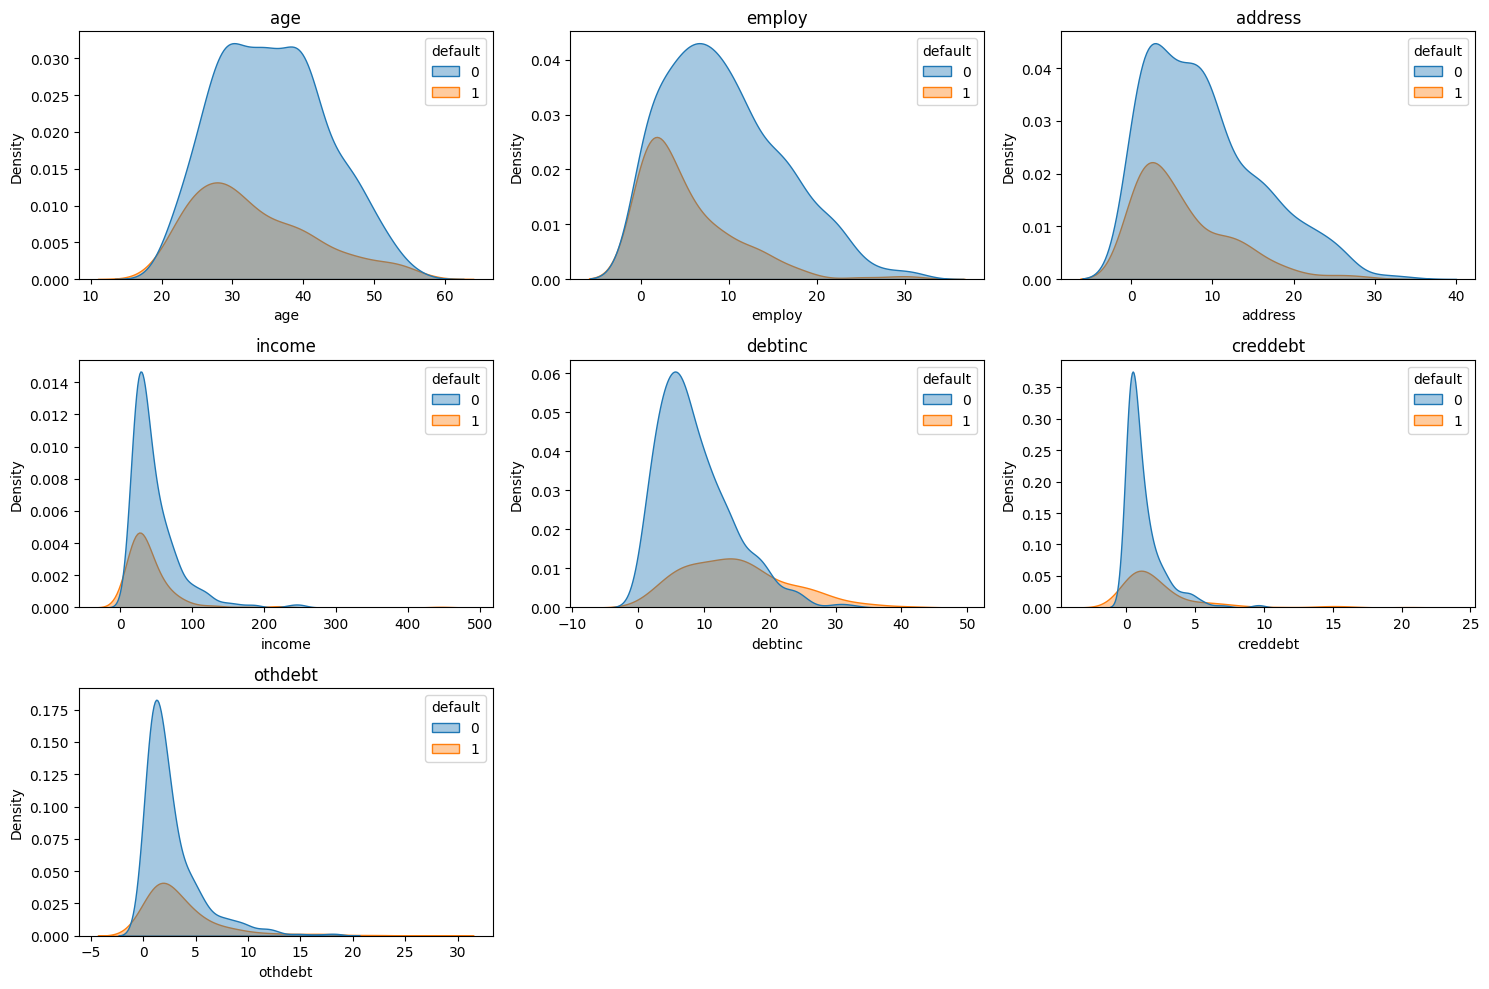

In [18]:
#Distributions by class — the core plot, showing which features separate defaulters:
num_cols = ['age', 'employ', 'address', 'income', 'debtinc', 'creddebt', 'othdebt']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, num_cols):
    sns.kdeplot(data=train, x=col, hue='default', fill=True, alpha=0.4, ax=ax)
    ax.set_title(col)
for ax in axes.flat[len(num_cols):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

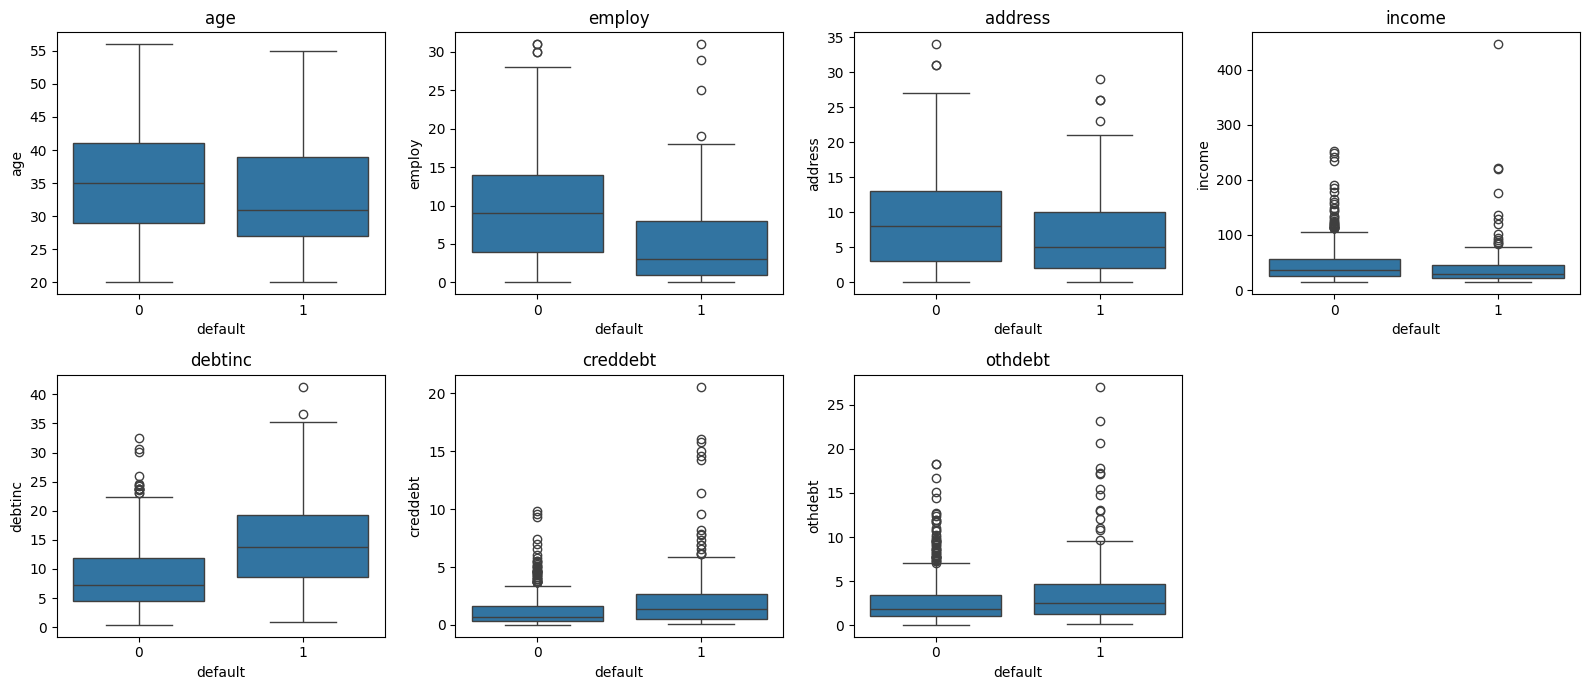

In [19]:
#Boxplots make the group gaps easier to read:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=train, x='default', y=col, ax=ax)
    ax.set_title(col)
axes.flat[-1].axis('off')
plt.tight_layout(); plt.show()

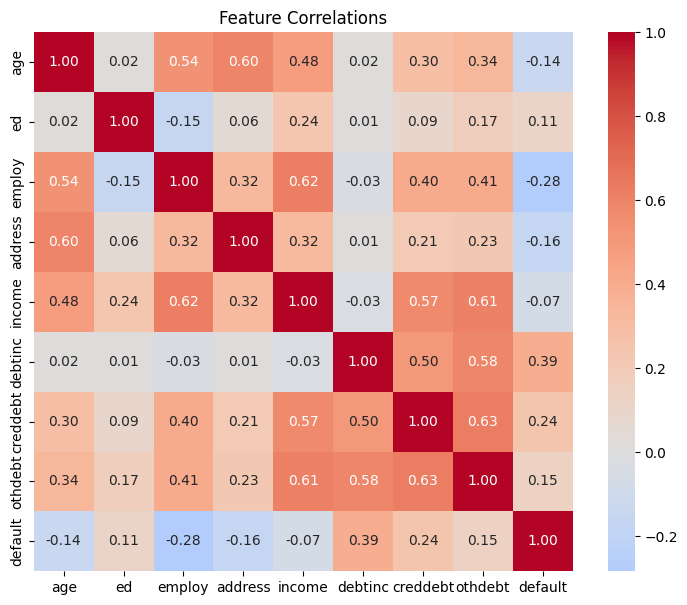

In [20]:
#Correlation heatmap:
plt.figure(figsize=(9, 7))
sns.heatmap(train.corr(numeric_only=True), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlations')
plt.show()

     mean  count
ed              
1   0.212    372
2   0.298    198
3   0.345     87
4   0.368     38
5   0.200      5


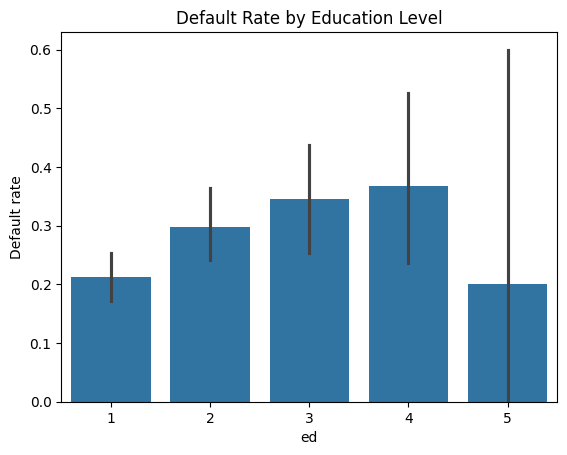

In [21]:
#Education level, which is categorical despite the integer coding:
ed_rate = train.groupby('ed')['default'].agg(['mean', 'count'])
print(ed_rate.round(3))

sns.barplot(data=train, x='ed', y='default')
plt.ylabel('Default rate'); plt.title('Default Rate by Education Level')
plt.show()

In [22]:
#Group comparison table for your writeup:
print(train.groupby('default')[num_cols].mean().round(2).T)

default       0      1
age       35.51  33.01
employ     9.51   5.22
address    8.95   6.39
income    47.15  41.21
debtinc    8.68  14.73
creddebt   1.25   2.42
othdebt    2.77   3.86


In [23]:
#Clean the dataset:
# Encode categorical variables.
X = train.drop(columns=['default'])
y = train['default']

# Option A: treat ed as ordinal (1 < 2 < 3 < 4 < 5) — leave as-is
# Option B: one-hot, makes no assumption about spacing
X = pd.get_dummies(X, columns=['ed'], prefix='ed', drop_first=True)
print(X.columns.tolist())

['age', 'employ', 'address', 'income', 'debtinc', 'creddebt', 'othdebt', 'ed_2', 'ed_3', 'ed_4', 'ed_5']


In [25]:
#Normalization inside a pipeline, so the scaler fits only on training folds:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

pipe.fit(X_train, y_train)
print(f"Test accuracy: {pipe.score(X_test, y_test):.3f}")

Test accuracy: 0.764


In [28]:
holdout = loan[loan['default'].isna()].copy()
print(holdout.shape)   # (150, 9)

holdout_X = holdout.drop(columns=['default'])
holdout_X = pd.get_dummies(holdout_X, columns=['ed'], prefix='ed', drop_first=True)
holdout_X = holdout_X.reindex(columns=X.columns, fill_value=0)   # match column order

holdout['pred_default'] = pipe.predict(holdout_X)

(150, 9)


note 1: reindex handles the case where the holdout set happens to be missing an education level that appeared in training, without it you'd get a shape mismatch.

note 2: creddebt and othdebt: both are heavily right-skewed. StandardScaler centers and scales but doesn't fix skew. If you want to address it, np.log1p() on those two columns before scaling is the standard move, and worth a sentence in the writeup either way.

#Part 2: Feature Engineering
1. Create new features based on existing data to enhance prediction accuracy.
2. Scale numerical features to ensure consistency.

In [29]:
#1. Create new features based on existing data to enhance prediction accuracy.
def add_features(df):
    df = df.copy()

    # Total debt in absolute dollars (thousands)
    df['total_debt'] = df['creddebt'] + df['othdebt']

    # What share of debt is revolving credit — riskier than installment debt
    df['credit_debt_ratio'] = df['creddebt'] / df['total_debt'].replace(0, np.nan)

    # Debt burden expressed against income directly
    df['debt_to_income_abs'] = df['total_debt'] / df['income'].replace(0, np.nan)

    # Stability signals
    df['employ_ratio'] = df['employ'] / df['age']        # share of life employed
    df['stability'] = df['employ'] + df['address']       # combined tenure

    # Income per year of employment — earning trajectory
    df['income_per_employ_yr'] = df['income'] / (df['employ'] + 1)

    # Skew correction on the money columns
    for c in ['income', 'creddebt', 'othdebt', 'total_debt']:
        df[f'log_{c}'] = np.log1p(df[c])

    return df

train_fe = add_features(train)
holdout_fe = add_features(holdout)

print(train_fe.shape)
print(train_fe.isna().sum()[lambda s: s > 0])   # check the divisions

(700, 19)
Series([], dtype: int64)


note: The .replace(0, np.nan) guards against divide-by-zero. If any NaNs appear, fill them inside the pipeline rather than beforehand.

In [30]:
#Check whether the new features actually help before keeping them:
num = train_fe.select_dtypes('number')
corr = num.corr()['default'].drop('default').sort_values(key=abs, ascending=False)
print(corr.round(3))

debtinc                 0.390
debt_to_income_abs      0.390
employ_ratio           -0.306
employ                 -0.283
stability              -0.274
income_per_employ_yr    0.249
creddebt                0.245
log_creddebt            0.238
total_debt              0.203
log_total_debt          0.193
address                -0.164
othdebt                 0.146
log_othdebt             0.142
credit_debt_ratio       0.142
age                    -0.138
log_income             -0.134
ed                      0.115
income                 -0.071
Name: default, dtype: float64


note: Anything near zero is noise, drop it. Adding features that don't separate the classes just adds variance.

In [33]:
#Scalling with the pipeline:
X = pd.get_dummies(train_fe.drop(columns=['default']), columns=['ed'],
                   prefix='ed', drop_first=True)
y = train_fe['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

cv = StratifiedKFold(5, shuffle=True, random_state=42)
print(f"CV ROC AUC: {cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc').mean():.3f}")

CV ROC AUC: 0.842


In [34]:
#Compare against baseline
X_base = pd.get_dummies(train.drop(columns=['default']), columns=['ed'],
                        prefix='ed', drop_first=True)
base_score = cross_val_score(pipe, X_base, y, cv=cv, scoring='roc_auc').mean()
print(f"Baseline: {base_score:.3f}")

Baseline: 0.844


#Part 3: Model Building and Evaluation
1. Split the data into training and testing sets.

In [35]:
X = pd.get_dummies(train.drop(columns=['default']), columns=['ed'],
                   prefix='ed', drop_first=True)
y = train['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("\nClass balance preserved:")
print(f"Train: {y_train.mean():.3f}")
print(f"Test:  {y_test.mean():.3f}")

Train: (560, 11), Test: (140, 11)

Class balance preserved:
Train: 0.261
Test:  0.264


note: stratify=y = with only 183 defaults in 700 rows, a random split could easily hand the test set an unrepresentative share. Stratifying forces both sides to keep the ~26% default rate.

random_state=42 = makes the split reproducible so your results don't shift between runs.

80/20 = 140 test rows is on the small side, meaning your test metrics will be noisy. That's the argument for reporting cross-validated scores on the training set alongside the single test number, rather than relying on the test set alone.

In [38]:
#2. Train a Random Forest classifier or another algorithm of your choice.
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
}

cv = StratifiedKFold(5, shuffle=True, random_state=42)
results = {}

for name, clf in models.items():
    pipe = Pipeline([('scale', StandardScaler()), ('clf', clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    results[name] = scores
    print(f"{name:22} {scores.mean():.3f} (+/- {scores.std():.3f})")

Logistic Regression    0.842 (+/- 0.029)
Decision Tree          0.674 (+/- 0.035)
Random Forest          0.797 (+/- 0.028)
SVM (RBF)              0.807 (+/- 0.022)


note: Scaling matters for SVM and logistic regression, both are distance/magnitude sensitive, and income ranges into the hundreds while debtinc sits under 40. Random Forest doesn't need it, but leaving it in the pipeline is harmless and keeps the code uniform

#Part 3: Evaluate the model using:
- Accuracy
- Confusion Matrix
- Classification Report (Precision, Recall, F1-Score)

In [39]:
#Fit the best one and evaluate on the test set:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

best = Pipeline([
    ('scale', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))
])
best.fit(X_train, y_train)

y_pred = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['No default', 'Default']))
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.3f}")

[[96  7]
 [19 18]]
              precision    recall  f1-score   support

  No default       0.83      0.93      0.88       103
     Default       0.72      0.49      0.58        37

    accuracy                           0.81       140
   macro avg       0.78      0.71      0.73       140
weighted avg       0.80      0.81      0.80       140

ROC AUC: 0.831


debtinc     0.183
employ      0.175
creddebt    0.160
othdebt     0.125
income      0.112
age         0.105
address     0.101
ed_2        0.018
ed_3        0.013
ed_4        0.007
dtype: float64


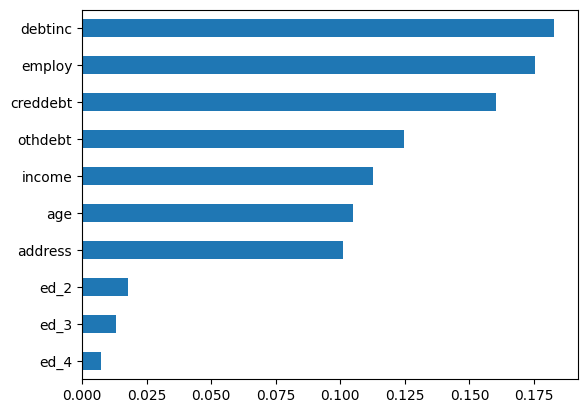

In [40]:
#Feature importances:
imp = pd.Series(best.named_steps['clf'].feature_importances_,
                index=X_train.columns).sort_values(ascending=False)
print(imp.head(10).round(3))
imp.head(10).plot(kind='barh').invert_yaxis()

note: with 700 rows and ~26% defaults, expect recall on the default class to be the weak spot. class_weight='balanced' helps, but you may still miss defaulters. For a lending context, a false negative (approving someone who defaults) usually costs more than a false positive, so it's worth lowering the threshold below 0.5 and reporting what that does to the confusion matrix.

debtinc     0.1828
employ      0.1753
creddebt    0.1601
othdebt     0.1247
income      0.1125
age         0.1048
address     0.1011
ed_2        0.0179
ed_3        0.0131
ed_4        0.0074
ed_5        0.0002
dtype: float64


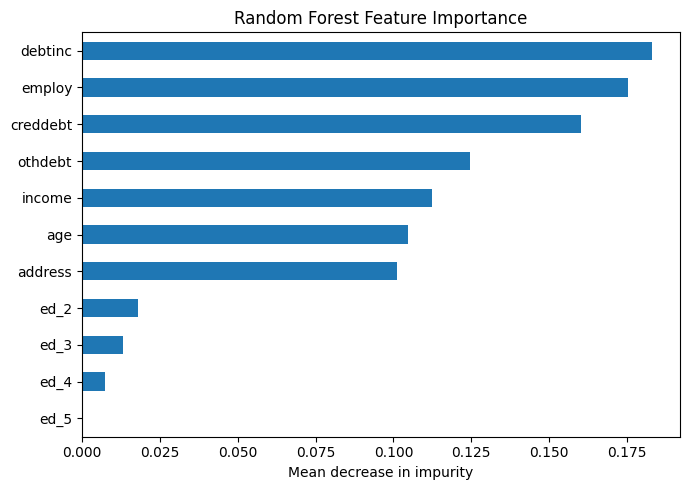

In [41]:
#4. Analyze feature importance to determine which factors impact loan defaults./ 3 angles: importance, permutation importance and
#the signed logistic coefficients.

# 1. Random Forest impurity-based importance
best.fit(X_train, y_train)
rf = best.named_steps['clf']

imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(imp.round(4))

imp.plot(kind='barh', figsize=(7, 5)).invert_yaxis()
plt.xlabel('Mean decrease in impurity')
plt.title('Random Forest Feature Importance')
plt.tight_layout(); plt.show()


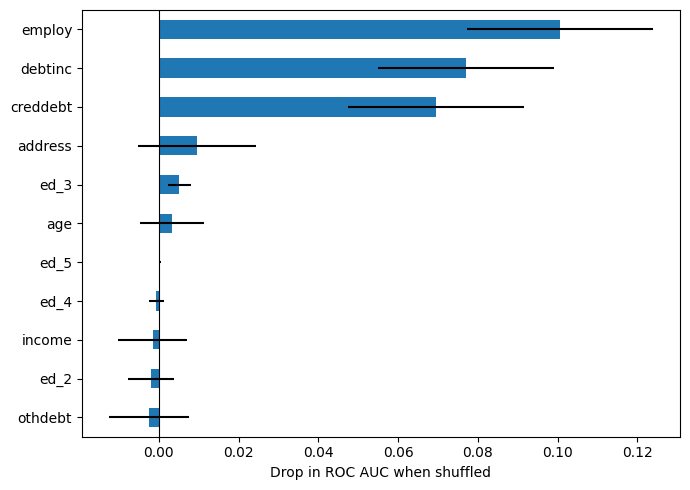

In [44]:
#Permutation importance : more trustworthy, because impurity importance inflates high-cardinality continuous features
r = permutation_importance(best, X_test, y_test, n_repeats=30,
                           random_state=42, scoring='roc_auc')

perm = pd.Series(r.importances_mean, index=X_train.columns).sort_values(ascending=False)
err  = pd.Series(r.importances_std,  index=X_train.columns)[perm.index]

perm.plot(kind='barh', xerr=err, figsize=(7, 5)).invert_yaxis()
plt.xlabel('Drop in ROC AUC when shuffled')
plt.axvline(0, color='black', lw=0.8)
plt.tight_layout(); plt.show()

note: Anything whose error bar crosses zero isn't contributing reliably.

          coefficient  odds_ratio
employ         -1.711       0.181
address        -0.702       0.495
income         -0.249       0.779
ed_5           -0.194       0.824
ed_4           -0.035       0.966
ed_3            0.152       1.164
othdebt         0.152       1.164
ed_2            0.242       1.273
age             0.299       1.349
debtinc         0.436       1.546
creddebt        1.169       3.220


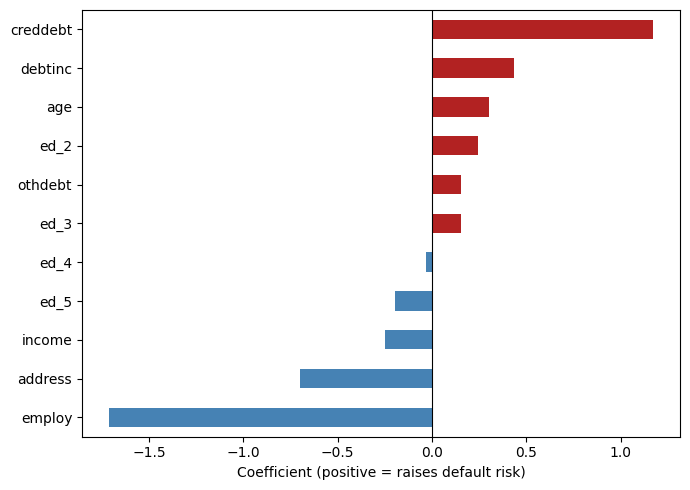

In [45]:
#Direction of effect = importance tells you a feature matters, not which way it pushes:
lr = Pipeline([('scale', StandardScaler()),
               ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])
lr.fit(X_train, y_train)

coef = pd.Series(lr.named_steps['clf'].coef_[0], index=X_train.columns).sort_values()
odds = np.exp(coef)

print(pd.DataFrame({'coefficient': coef.round(3), 'odds_ratio': odds.round(3)}))

coef.plot(kind='barh', figsize=(7, 5),
          color=['firebrick' if c > 0 else 'steelblue' for c in coef])
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Coefficient (positive = raises default risk)')
plt.tight_layout(); plt.show()

note: Since the features are standardized, coefficients are directly comparable. An odds ratio of 2.1 on debtinc means each one-standard-deviation rise in debt-to-income roughly doubles the odds of default.

Analysis: debtinc comes out on top across all three methods, the single clearest risk factor. employ is second and negative: each additional year with an employer lowers default odds. creddebt is positive; address negative but weaker. age and income contribute little on their own, which is the interesting result, income alone doesn't predict default, but income relative to debt does.

#Part  4: Explainability and Fairness Analysis

In [46]:
#1. Use SHAP to explain model predictions and interpret the results.
# Refit so explainer and model are the same fitted object
best.fit(X_train, y_train)
rf = best.named_steps['clf']
scaler = best.named_steps['scale']

# SHAP needs the data in the form the classifier sees it
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns)

explainer = shap.TreeExplainer(rf)
sv = explainer(X_test_s)

# Binary RF returns (n_samples, n_features, n_classes) — take the default class
if sv.values.ndim == 3:
    sv = sv[:, :, 1]

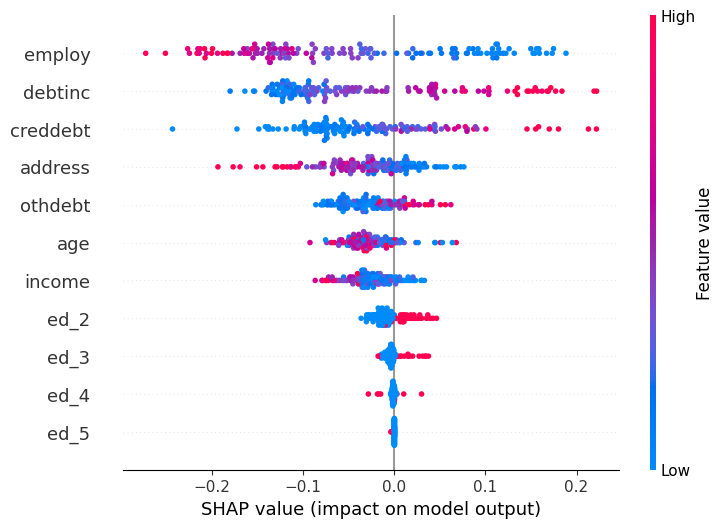

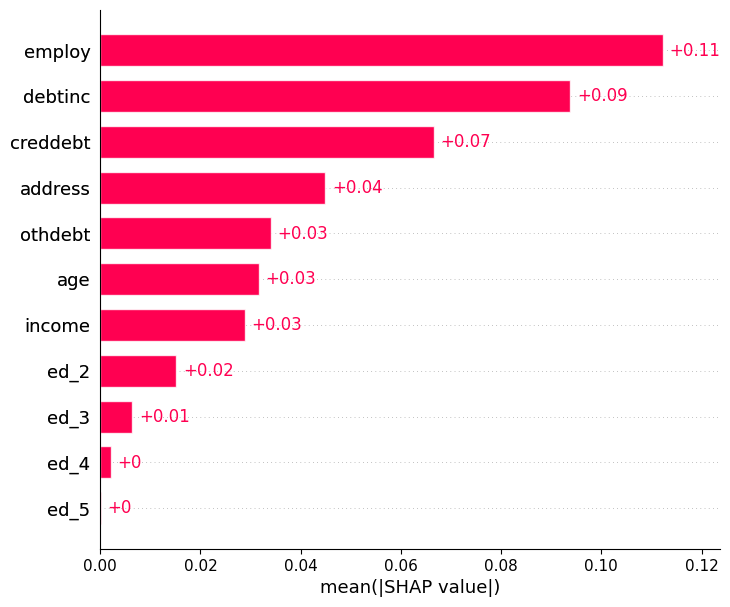

In [47]:
#Global Explanation
shap.plots.beeswarm(sv, max_display=12)
shap.plots.bar(sv, max_display=12)

Analysis: Each dot is an applicant; horizontal position is the push toward or away from default; color is the feature's value. You should see debtinc spread widest, with red dots (high debt-to-income) sitting on the positive side, and employ mirrored, red dots (long tenure) on the negative side.

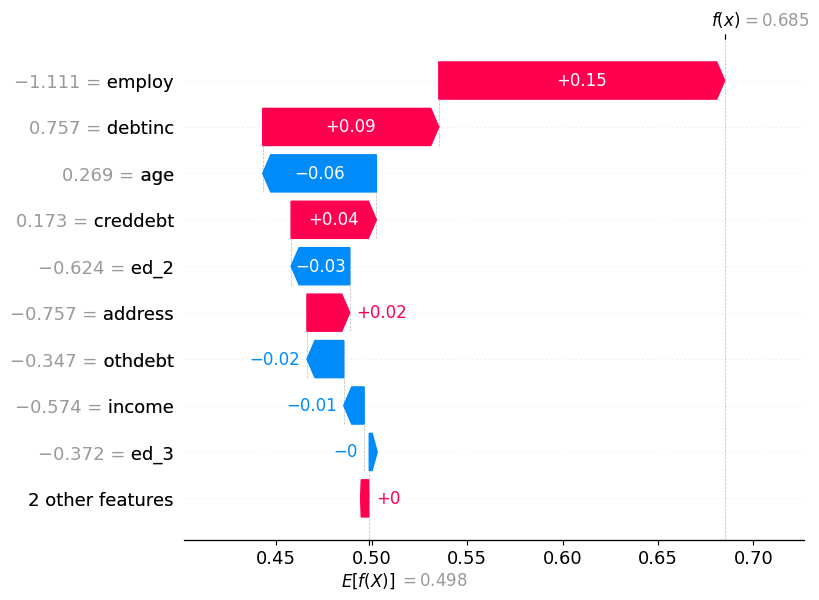

Predicted default probability: 0.685
Actual: 1
age               37
employ             1
address            3
income            24
debtinc         15.1
creddebt    1.801128
othdebt     1.822872
ed_2           False
ed_3           False
ed_4           False
ed_5           False
Name: 55, dtype: object


In [48]:
#Individual prediction, the explainability deliverable:
i = 0
shap.plots.waterfall(sv[i], max_display=10)

print(f"Predicted default probability: {best.predict_proba(X_test.iloc[[i]])[0,1]:.3f}")
print(f"Actual: {y_test.iloc[i]}")
print(X_test.iloc[i])

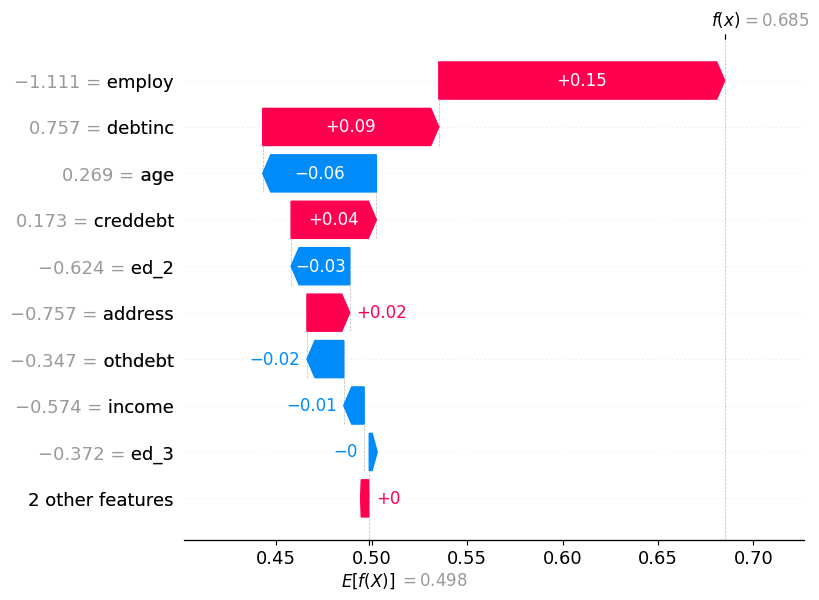

In [49]:
#Pick a genuine default to explain, more informative than a random row:
idx = np.where((y_test.values == 1) & (best.predict(X_test) == 1))[0][0]
shap.plots.waterfall(sv[idx], max_display=10)

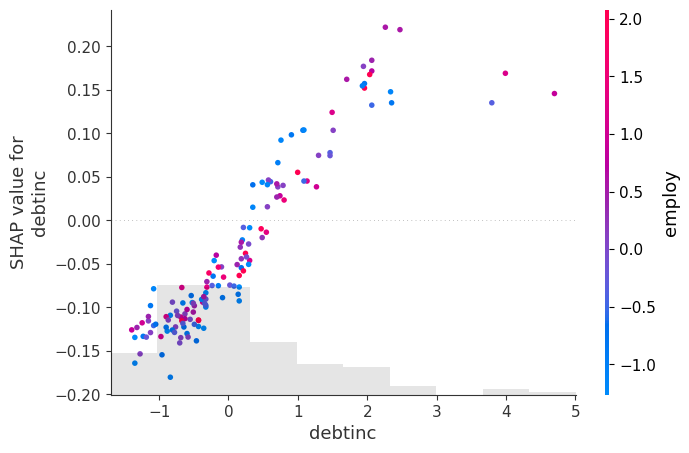

In [50]:
#Dependence plot, shows the shape of the relationship, not just its strength:
shap.plots.scatter(sv[:, 'debtinc'], color=sv[:, 'employ'])

Analysis: SHAP values stay flat until debtinc crosses roughly 10–15, then climb sharply. That's a business-usable finding, it suggests a screening cutoff rather than a smooth risk gradient.

SHAP attributes the model's reasoning, not reality. If the model learned a spurious pattern, SHAP will faithfully explain the spurious pattern. It's a transparency tool, not a validation one

In [51]:
#2. Assess fairness by comparing model performance across demographic groups
best.fit(X_train, y_train)
y_pred = best.predict(X_test)

audit = X_test.copy()
audit['y_true'] = y_test.values
audit['y_pred'] = y_pred

audit['age_group'] = pd.cut(audit['age'], bins=[0, 30, 40, 50, 100],
                            labels=['<30', '30-39', '40-49', '50+'])

def group_metrics(df, attr):
    rows = []
    for g in df[attr].dropna().unique():
        m = df[attr] == g
        tn, fp, fn, tp = confusion_matrix(df.loc[m, 'y_true'], df.loc[m, 'y_pred'],
                                          labels=[0, 1]).ravel()
        rows.append({
            'group': g,
            'n': int(m.sum()),
            'base_rate': df.loc[m, 'y_true'].mean(),      # actual default rate
            'selection_rate': df.loc[m, 'y_pred'].mean(), # % flagged as risky
            'TPR': tp / (tp + fn) if (tp + fn) else np.nan,
            'FPR': fp / (fp + tn) if (fp + tn) else np.nan,
            'precision': tp / (tp + fp) if (tp + fp) else np.nan
        })
    return pd.DataFrame(rows).sort_values('group')

res = group_metrics(audit, 'age_group')
print(res.round(3))

ratio = res['selection_rate'].min() / res['selection_rate'].max()
print(f"\nSelection rate ratio: {ratio:.3f}  (80% rule threshold: 0.80)")

   group   n  base_rate  selection_rate    TPR    FPR  precision
0  30-39  63      0.206           0.159  0.538  0.060      0.700
1  40-49  27      0.185           0.074  0.400  0.000      1.000
3    50+   6      0.500           0.000  0.000  0.000        NaN
2    <30  44      0.364           0.295  0.562  0.143      0.692

Selection rate ratio: 0.000  (80% rule threshold: 0.80)


In [52]:
#Same for Education
ed_cols = [c for c in X_test.columns if c.startswith('ed_')]
audit['ed_level'] = X_test[ed_cols].idxmax(axis=1).where(X_test[ed_cols].any(axis=1), 'ed_1')
print(group_metrics(audit, 'ed_level').round(3))

  group   n  base_rate  selection_rate    TPR    FPR  precision
0  ed_1  67      0.254           0.149  0.529  0.020      0.900
1  ed_2  41      0.171           0.220  0.571  0.147      0.444
3  ed_3  19      0.421           0.263  0.500  0.091      0.800
2  ed_4  10      0.400           0.100  0.250  0.000      1.000
4  ed_5   3      0.333           0.000  0.000  0.000        NaN


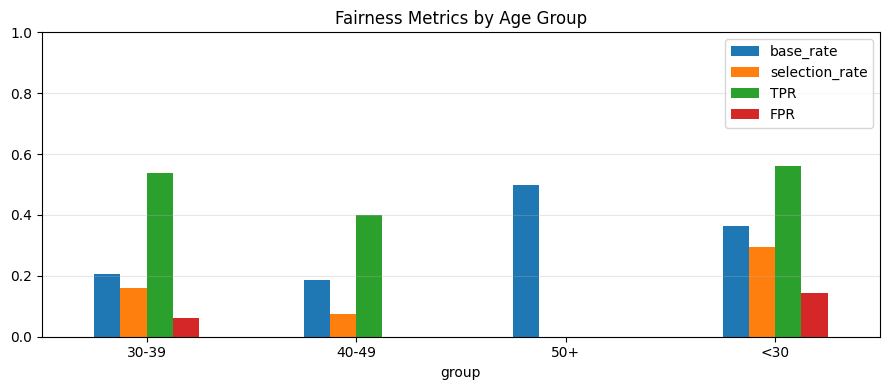

In [53]:
#Visual
res.set_index('group')[['base_rate', 'selection_rate', 'TPR', 'FPR']].plot(
    kind='bar', figsize=(9, 4), rot=0)
plt.ylim(0, 1); plt.grid(axis='y', alpha=0.3)
plt.title('Fairness Metrics by Age Group'); plt.tight_layout(); plt.show()

Analysis: Younger applicants genuinely default more in this data, so a higher selection rate for them partly reflects reality rather than bias. The question is whether the gap exceeds the base-rate difference. If <30,  has a base rate of 0.35 and a selection rate of 0.35, that's calibated. If it's flagged at 0.55, the model is over-penalizing beyond what the outcomes justify.

FPR is the one that matters most for lending harm: a false positive means a creditworthy applicant is denied. A group with a materially higher FPR is bearing the cost of the model's errors.

Group sizes after splitting are small, some age bands will have 20–30 rows in a 140-row test set, so the metrics are noisy.

In [57]:
#Cross Validated predcitions over the full labeled set for more stable numbers
y_cv = cross_val_predict(best, X, y, cv=cv)

print(confusion_matrix(y, y_cv))
print(classification_report(y, y_cv, target_names=['No default', 'Default']))
print(f"ROC AUC: {roc_auc_score(y, y_cv):.3f}")

[[476  41]
 [109  74]]
              precision    recall  f1-score   support

  No default       0.81      0.92      0.86       517
     Default       0.64      0.40      0.50       183

    accuracy                           0.79       700
   macro avg       0.73      0.66      0.68       700
weighted avg       0.77      0.79      0.77       700

ROC AUC: 0.663
